In [2]:
import pandas as pd
df=pd.read_csv("C:\\Users\\akhil\\Downloads\\tested.csv") 

In [3]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [4]:
df.shape

(418, 12)

In [5]:
df.head() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
df.describe() 

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [7]:
df.isnull().sum() 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [8]:
df.drop('Cabin', axis=1, inplace=True)   #to drop the entire column - becoz of heavy missing values

In [9]:
df = df.drop(columns=["PassengerId","Ticket", "Name"])
                  # or / If you pass multiple labels without columns= or index=, they must be in a list or array, not as separate arguments.
df = df.drop(["PassengerId", "Ticket", "Name"], axis=1)

In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median()) 
df.isnull().sum() 

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [11]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = numeric_df[
    (numeric_df < (Q1 - 1.5 * IQR)) |
    (numeric_df > (Q3 + 1.5 * IQR))
]


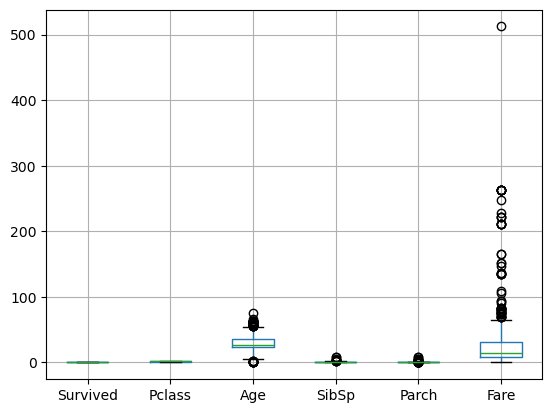

In [12]:
import matplotlib.pyplot as plt
df.boxplot()
plt.show()

Accuracy (Logistic): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

----------------------------------
Accuracy (Random Forest): 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

----------------------------------
Accuracy (SVM): 0.9880952380952381
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.99        34

    accuracy          

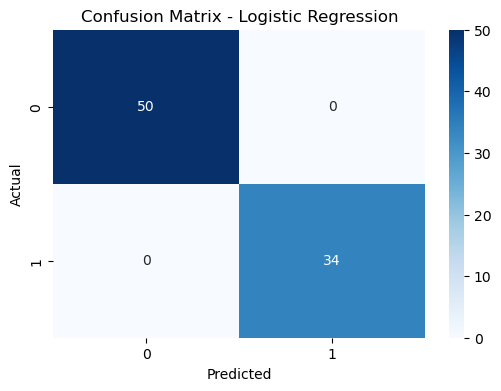

In [14]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt    
import seaborn as sns
from sklearn.compose import ColumnTransformer

numeric_cols = ["Age", "Fare", "SibSp", "Parch"]
categorical_cols = ["Sex", "Embarked"]

# Features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[ 
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols) 
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# After train-test split, "StandardScaler is applied to numeric columns" and "One-Hot Encoding to categorical columns",
#  both fitted on training data and applied to test data.

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# ---------------- MODELS ---------------- #

# Logistic Regression 
lg = LogisticRegression(max_iter=1000) 
lg.fit(X_train_processed, y_train) 
pred1 = lg.predict(X_test_processed) 

# Random Forest (scaling not required, but OK)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_processed, y_train)
pred2 = rf.predict(X_test_processed)

# SVM (scaling REQUIRED)
sv = SVC()
sv.fit(X_train_processed, y_train)
pred3 = sv.predict(X_test_processed)

# ---------------- EVALUATION ---------------- #

print('Accuracy (Logistic):', accuracy_score(y_test, pred1))
print(classification_report(y_test, pred1))

print('----------------------------------')

print('Accuracy (Random Forest):', accuracy_score(y_test, pred2))
print(classification_report(y_test, pred2))

print('----------------------------------') 

print('Accuracy (SVM):', accuracy_score(y_test, pred3)) 
print(classification_report(y_test, pred3)) 

# Confusion Matrix
cm = confusion_matrix(y_test, pred1)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

